# Actividad práctica — Visualización con Matplotlib
### Dataset: Encuesta de hogares Argentina

> Completá o modificá el código en cada ejercicio. Los espacios marcados con `___` son los que tenés que completar.
> Cada ejercicio tiene una o dos preguntas de reflexión para responder en Markdown.
---

## Setup — ejecutar antes de comenzar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('hogares_argentina.csv')
df_viz = df[df['ingreso_mensual'] < df['ingreso_mensual'].quantile(0.97)].copy()

print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 800 filas, 12 columnas


,region,nivel_educativo,tipo_empleo,tipo_vivienda,miembros_hogar,ingreso_mensual,gasto_alimentos,gasto_vivienda,gasto_salud,gasto_educacion,ahorro_mensual,acceso_servicios
0,Pampeana,Terciario,Informal,Casa propia,2,206578,64267,48508,2057,7183.0,80011.0,4.5
1,AMBA,Primario,Formal,Casa propia,4,387882,161228,103773,30527,871.0,79473.0,1.1
2,AMBA,Secundario,Informal,Casa propia,2,154754,59114,62921,5487,13709.0,7046.0,3.2
3,Patagonia,Terciario,Formal,Casa propia,3,382296,122628,83032,18048,23257.0,118640.0,1.9
4,NEA,Secundario,Informal,Alquilada,3,132911,39275,15684,6392,17101.0,NaN,1.9


---
## Ejercicio 1 — Interfaz orientada a objetos

El siguiente código usa la **interfaz estilo MATLAB** (`plt.`).
Reescribilo usando la **interfaz orientada a objetos** (`fig, ax`).
El gráfico resultante debe ser idéntico al original.

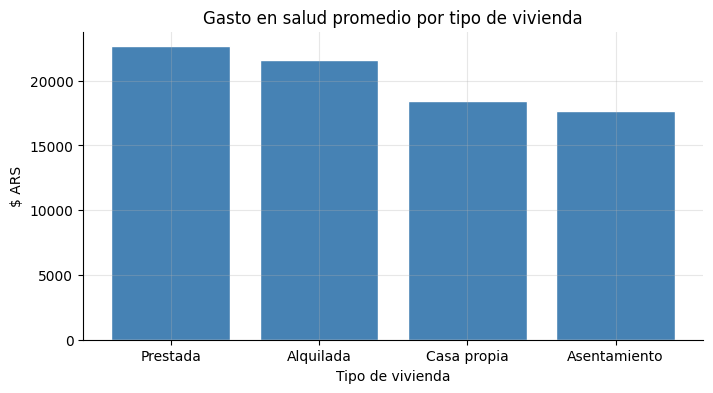

In [ ]:
# ── CÓDIGO ORIGINAL — interfaz MATLAB — no modificar ──
gastos = (df.groupby('tipo_vivienda')['gasto_salud']
           .mean().sort_values(ascending=False))

plt.figure(figsize=(8, 4))
plt.bar(gastos.index, gastos.values, color='steelblue', edgecolor='white')
plt.title('Gasto en salud promedio por tipo de vivienda')
plt.xlabel('Tipo de vivienda')
plt.ylabel('$ ARS')
plt.show()

In [ ]:
# ── TU SOLUCIÓN — reescribir con interfaz orientada a objetos ──
gastos = (df.groupby('tipo_vivienda')['gasto_salud']
           .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))

___.___(gastos.index, gastos.values, color='steelblue', edgecolor='white')
ax.set_title(___)
ax.set_xlabel(___)
ax._________(___)
plt.show()

**Para responder:**
- ¿Qué diferencia hay entre `plt.title()` y `ax.set_title()`?
- ¿En qué situaciones conviene usar la interfaz orientada a objetos?

*Doble clic acá para escribir tu respuesta:*

---
## Ejercicio 2 — Histograma con líneas de referencia

Completá el histograma del **gasto en vivienda** que incluya:
- La **media** como línea vertical roja punteada
- La **mediana** como línea vertical naranja punteada
- El **percentil 75 (Q3)** como línea vertical verde punteada
- Una **leyenda** que muestre los tres valores

In [ ]:
datos = df_viz['gasto_vivienda']
datos = datos[datos < datos.quantile(0.97)]

# Calcular las medidas
media   = datos.___()
mediana = datos.___()
q3      = datos.___(0.75)

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma — elegir una cantidad de bins entre 25 y 50
ax.hist(datos, bins=___, color='seagreen', edgecolor='white', alpha=0.8)

# Líneas de referencia — completar color y linestyle de cada una
ax.axvline(media,   color=___, linestyle=___, linewidth=2,
           label=f'Media: \${media:,.0f}')
ax.axvline(mediana, color=___, linestyle=___, linewidth=2,
           label=f'Mediana: \${mediana:,.0f}')
ax.axvline(q3,      color=___, linestyle=___, linewidth=2,
           label=f'Q3: \${q3:,.0f}')

ax.set_title('Distribución del gasto en vivienda con líneas de referencia',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gasto en vivienda ($ ARS)')
ax.set_ylabel('Frecuencia')
ax.___()   # agregar la leyenda
plt.tight_layout()
plt.show()

**Para responder:**
- ¿La media es mayor o menor que la mediana? ¿Qué indica eso sobre la distribución?
- ¿Qué porcentaje de hogares tiene un gasto en vivienda menor que Q3?

*Doble clic acá para escribir tu respuesta:*

---
## Ejercicio 3 — Scatter con anotación

Completá el scatter entre **ingreso mensual** y **gasto en salud**. El gráfico debe incluir:
- Una **línea de tendencia** lineal en rojo
- Una **anotación con flecha** que señale el hogar con mayor gasto en salud

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = df_viz['ingreso_mensual']
y = df_viz['gasto_salud']

# Scatter — completar alpha y tamaño de puntos
ax.___(x, y, alpha=___, color='darkorange', s=___)

# Línea de tendencia — ajustar una recta entre x e y
z = np.polyfit(___, ___, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2, label='Tendencia')

# Anotación — señalar el hogar con mayor gasto en salud
idx_max = y.idxmax()
ax.annotate('Mayor gasto en salud',
            xy=(x[idx_max], ___[______]),          # punto señalado
            xytext=(x[idx_max] - 150000, y[idx_max] - 30000),  # posición del texto
            fontsize=10,
            arrowprops=dict(facecolor='black', shrink=0.05))

ax.set_title(___)
ax.set_xlabel('Ingreso mensual ($ ARS)')
ax.set_ylabel('Gasto en salud ($ ARS)')
ax.legend()
plt.tight_layout()
plt.show()

**Para responder:**
- ¿La relación entre ingreso y gasto en salud parece fuerte o moderada? ¿Por qué?
- ¿El hogar con mayor gasto en salud tiene también el ingreso más alto?

*Doble clic acá para escribir tu respuesta:*

---
## Ejercicio 4 — Superponer distribuciones ⏱️ 6 min

Completá el código para mostrar la distribución del **ahorro mensual** separada por **nivel educativo**.
Usá `histtype='stepfilled'` con `alpha=0.4`. Filtrá los valores negativos antes de graficar.

In [ ]:
# Filtrar valores negativos y outliers extremos
df_ahorro = df_viz[df_viz['ahorro_mensual'] > 0].copy()
df_ahorro = df_ahorro[df_ahorro['ahorro_mensual'] < df_ahorro['ahorro_mensual'].quantile(0.97)]

orden_edu = ['Sin instrucción', 'Primario', 'Secundario', 'Terciario', 'Universitario']
colores   = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']

fig, ax = plt.subplots(figsize=(11, 5))

for nivel, color in zip(orden_edu, colores):
    # Filtrar los datos de ese nivel educativo
    datos = df_ahorro[df_ahorro['___'] == nivel]['___']
    ax.hist(datos, bins=___, alpha=___, color=color,
            edgecolor='white', label=nivel, histtype='stepfilled')

ax.set_title('Distribución del ahorro mensual por nivel educativo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ahorro mensual ($ ARS)')
ax.set_ylabel('Frecuencia')
ax.legend(title=___)
plt.tight_layout()
plt.show()

**Para responder:**
- ¿Los hogares universitarios ahorran más que los primarios? ¿Cómo se ve en el gráfico?
- ¿Las distribuciones se solapan mucho o poco entre niveles educativos?

*Doble clic acá para escribir tu respuesta:*

---
## Ejercicio 5 — Subplots comparativos

Completá la grilla de **2×2** que muestra la distribución de las cuatro variables de gasto.
Usá `axes.flat` para recorrer los paneles con un solo loop.

In [ ]:
vars_gasto = ['gasto_alimentos', 'gasto_vivienda', 'gasto_salud', 'gasto_educacion']
titulos    = ['Alimentos', 'Vivienda', 'Salud', 'Educación']
colores    = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

# Crear la grilla — completar filas y columnas
fig, axes = plt.subplots(___, ___, figsize=(12, 8))

# Completar axes.___ para recorrer los paneles con un solo loop
for ax, var, titulo, color in zip(axes.___, vars_gasto, titulos, colores):
    datos = df_viz[var].dropna()
    datos = datos[datos < datos.quantile(0.97)]
    # Completar el tipo de gráfico
    ax.___(datos, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('$ ARS')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de los cuatro gastos del hogar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Para responder:**
- ¿Cuál de los cuatro gastos tiene la distribución más sesgada hacia la derecha?

*Doble clic acá para escribir tu respuesta:*